
DETEKSI PENYAKIT DAUN TOMAT
PERBANDINGAN CNN DAN MobileNetV2


In [33]:

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("TensorFlow :", tf.__version__)

TensorFlow : 2.20.0


In [34]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [35]:
from google.colab import files

uploaded = files.upload()

Saving dataset-20260717T143857Z-1-001.zip to dataset-20260717T143857Z-1-001.zip


In [93]:
import os

rename_map = {
    "Early_blight": "Early_Blight",
    "Late_blight": "Late_Blight",
    "healthy": "Healthy"
}

for old_name, new_name in rename_map.items():
    old_path = os.path.join(valid_path, old_name)
    new_path = os.path.join(valid_path, new_name)

    if os.path.exists(old_path) and not os.path.exists(new_path):
        os.rename(old_path, new_path)
        print(f"{old_name} -> {new_name}")

In [95]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data Training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Data Validasi
valid_datagen = ImageDataGenerator(
    rescale=1./255
)

In [116]:
train_cnn = train_datagen.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

valid_cnn = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 8619 images belonging to 3 classes.
Found 2240 images belonging to 3 classes.


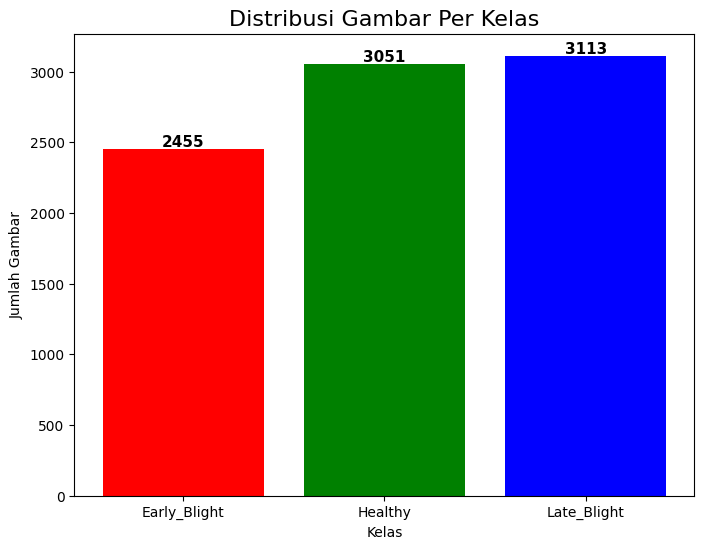

In [280]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

bars = plt.bar(
    classes,
    jumlah,
    color=['red', 'green', 'blue']
)

plt.title("Distribusi Gambar Per Kelas", fontsize=16)
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        y+20,
        int(y),
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.savefig("Gambar_Distribusi.png", dpi=300, bbox_inches="tight")
plt.show()

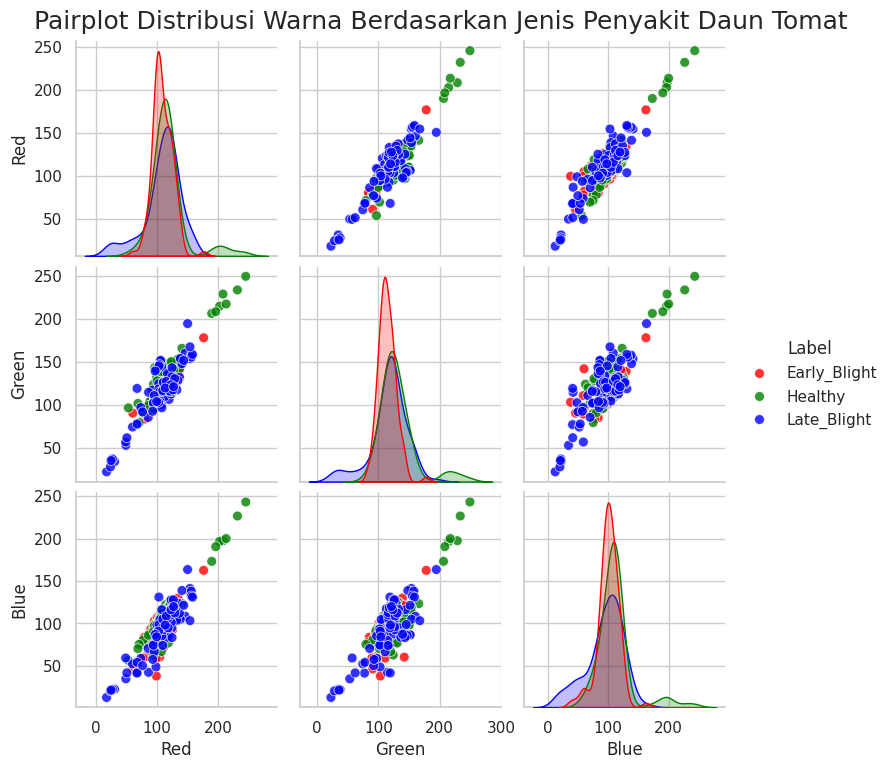

In [287]:
import os
import cv2
import random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


dataset_path = "/content/dataset/train"

kelas = ["Early_Blight", "Healthy", "Late_Blight"]

data = []

# Ambil 100 gambar tiap kelas agar proses cepat
for label in kelas:
    folder = os.path.join(dataset_path, label)

    gambar = os.listdir(folder)
    random.shuffle(gambar)

    for file in gambar[:100]:

        path = os.path.join(folder, file)

        img = cv2.imread(path)

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        r = img[:,:,0].mean()
        g = img[:,:,1].mean()
        b = img[:,:,2].mean()

        data.append([r,g,b,label])

# DataFrame
df = pd.DataFrame(data,columns=["Red","Green","Blue","Label"])


sns.set(style="whitegrid")

pair = sns.pairplot(
    df,
    hue="Label",
    diag_kind="kde",
    palette={
        "Early_Blight":"red",
        "Healthy":"green",
        "Late_Blight":"blue"
    },
    plot_kws={"s":50,"alpha":0.8}
)

pair.fig.suptitle(
    "Pairplot Distribusi Warna Berdasarkan Jenis Penyakit Daun Tomat",
    y=1.02,
    fontsize=18
)

plt.savefig("Pairplot_Daun_Tomat.png",dpi=300,bbox_inches="tight")

plt.show()

In [291]:
from google.colab import files
files.download("Pairplot_Daun_Tomat.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [87]:
import os

os.rename("/content/dataset/valid/Early_blight",
          "/content/dataset/valid/Early_Blight")

os.rename("/content/dataset/valid/Late_blight",
          "/content/dataset/valid/Late_Blight")

os.rename("/content/dataset/valid/healthy",
          "/content/dataset/valid/Healthy")

In [36]:
from PIL import Image
import os

bad_images = []

for folder in [train_path, valid_path]:
    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                path = os.path.join(root, file)
                try:
                    img = Image.open(path)
                    img.verify()
                except Exception:
                    bad_images.append(path)

print("Jumlah gambar rusak :", len(bad_images))

for img in bad_images:
    print(img)

Jumlah gambar rusak : 0


In [37]:
from PIL import Image
import os

hapus = 0

for folder in [train_path, valid_path]:
    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                path = os.path.join(root, file)
                try:
                    img = Image.open(path)
                    img.verify()
                except Exception:
                    print("Menghapus:", path)
                    os.remove(path)
                    hapus += 1

print(f"Total gambar rusak yang dihapus: {hapus}")

Total gambar rusak yang dihapus: 0


In [38]:
import os

DATASET_PATH = "/content/Dataset"

train_path = os.path.join(DATASET_PATH, "train")
valid_path = os.path.join(DATASET_PATH, "valid")

In [39]:
import os

print(os.listdir("/content"))

['.config', 'dataset.zip', 'dataset', 'dataset-20260717T143857Z-1-001.zip', 'sample_data']


In [40]:
train_path = "/content/dataset/train"
valid_path = "/content/dataset/valid"

In [41]:
classes = sorted(os.listdir(train_path))

jumlah = []

for kelas in classes:

    folder = os.path.join(train_path, kelas)

    jumlah.append(len(os.listdir(folder)))

for c, j in zip(classes, jumlah):
    print(c, ":", j)

Early_Blight : 2455
Healthy : 3051
Late_Blight : 3113


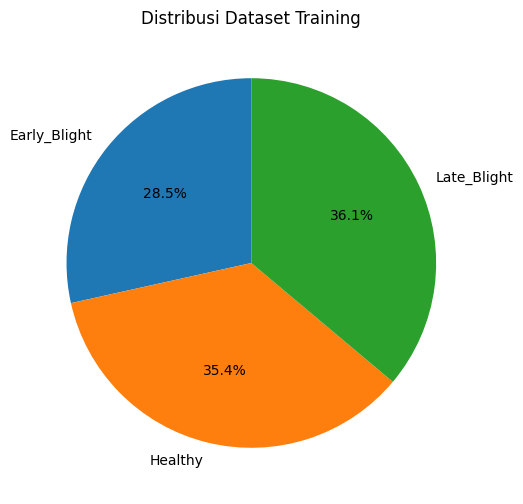

In [42]:
plt.figure(figsize=(6,6))

plt.pie(
    jumlah,
    labels=classes,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribusi Dataset Training")

plt.show()

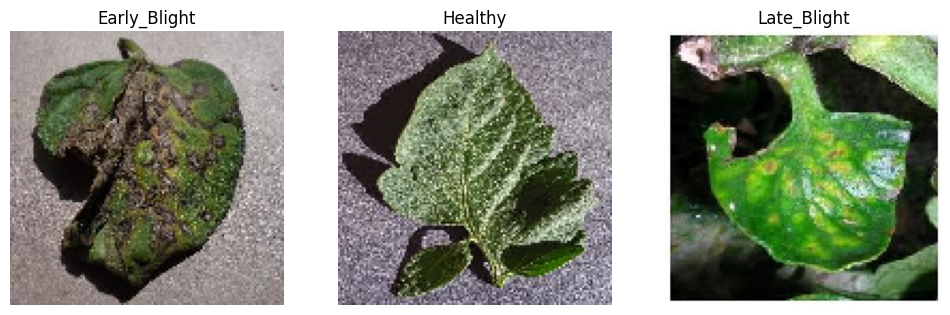

In [43]:
plt.figure(figsize=(12,12))

for i, kelas in enumerate(classes):

    folder = os.path.join(train_path, kelas)

    gambar = random.choice(os.listdir(folder))

    img = image.load_img(
        os.path.join(folder, gambar),
        target_size=(128,128)
    )

    plt.subplot(1,3,i+1)

    plt.imshow(img)

    plt.title(kelas)

    plt.axis("off")

plt.show()

In [44]:
train_datagen_cnn = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

valid_datagen_cnn = ImageDataGenerator(
    rescale=1./255
)

In [45]:
train_datagen_mobile = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen_mobile = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [46]:
train_cnn = train_datagen_cnn.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

valid_cnn = valid_datagen_cnn.flow_from_directory(
    valid_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 8619 images belonging to 3 classes.
Found 2240 images belonging to 3 classes.


In [47]:
train_mobile = train_datagen_mobile.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

valid_mobile = valid_datagen_mobile.flow_from_directory(
    valid_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 8619 images belonging to 3 classes.
Found 2240 images belonging to 3 classes.


In [48]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    save_best_only=True,
    monitor='val_accuracy'
)

MEMBANGUN MODEL CNN

In [239]:

cnn_model = Sequential([

    # Block 1
    Conv2D(32, (3,3), activation='relu',
           padding='same',
           input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Block 2
    Conv2D(64, (3,3), activation='relu',
           padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Block 3
    Conv2D(128, (3,3), activation='relu',
           padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Block 4
    Conv2D(256, (3,3), activation='relu',
           padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Mengurangi overfitting
    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(3, activation='softmax')

])

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 489,411 (1.87 MB)

 Trainable params: 488,451 (1.86 MB)

 Non-trainable params: 960 (3.75 KB)

In [241]:
from tensorflow.keras.optimizers import Adam

cnn_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

COMPILE MODEL CNN

In [244]:

cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [246]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [247]:
history_cnn = cnn_model.fit(
    train_cnn,
    validation_data=valid_cnn,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 79s 259ms/step - accuracy: 0.7061 - loss: 0.6874 - val_accuracy: 0.3938 - val_loss: 2.3099 - learning_rate: 1.0000e-04
Epoch 2/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 66s 244ms/step - accuracy: 0.8131 - loss: 0.4533 - val_accuracy: 0.7643 - val_loss: 0.5861 - learning_rate: 1.0000e-04
Epoch 3/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 63s 235ms/step - accuracy: 0.8507 - loss: 0.3938 - val_accuracy: 0.8763 - val_loss: 0.3615 - learning_rate: 1.0000e-04
Epoch 4/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 62s 229ms/step - accuracy: 0.8645 - loss: 0.3475 - val_accuracy: 0.7888 - val_loss: 0.7269 - learning_rate: 1.0000e-04
Epoch 5/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.8841 - loss: 0.3073
Epoch 5: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
270/270 ━━━━━━━━━━━━━━━━━━━━ 63s 232ms/step - accuracy: 0.8861 - loss: 0.3059 - val_accuracy: 0.8473 - val_loss: 0.4253 - learning_rate: 1.0000e-04
Epoch 6/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 63s 233ms/s

In [248]:

cnn_loss, cnn_accuracy = cnn_model.evaluate(valid_cnn)

print("CNN Accuracy :",round(cnn_accuracy*100,2),"%")
print("CNN Loss :",round(cnn_loss,4))

70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - accuracy: 0.9205 - loss: 0.2242
CNN Accuracy : 92.05 %
CNN Loss : 0.2242


70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step


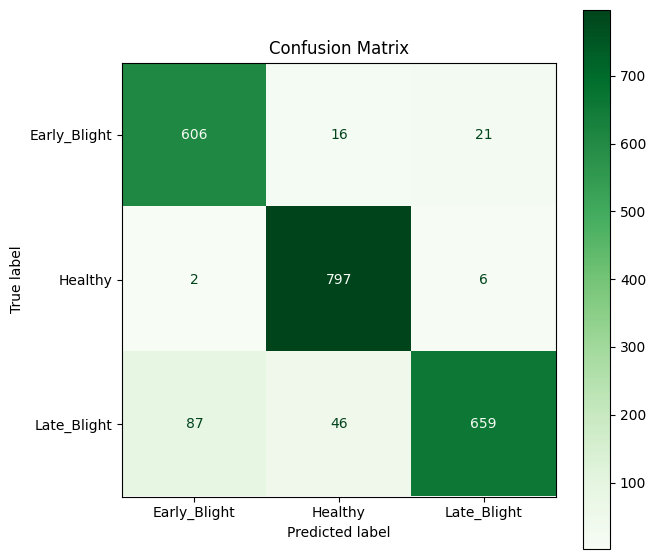

In [285]:

prediction = cnn_model.predict(valid_cnn)

prediction = np.argmax(prediction,axis=1)

true_label = valid_cnn.classes

cm = confusion_matrix(true_label,prediction)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(train_cnn.class_indices.keys())
)

fig,ax = plt.subplots(figsize=(7,7))

disp.plot(ax=ax,cmap="Greens")

plt.title("Confusion Matrix")


plt.savefig("Gambar_Distribusi.png")
plt.show()

In [286]:
from google.colab import files
files.download("Gambar_Distribusi.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [250]:

print(classification_report(
    true_label,
    prediction,
    target_names=list(train_cnn.class_indices.keys())
))

              precision    recall  f1-score   support

Early_Blight       0.87      0.94      0.91       643
     Healthy       0.93      0.99      0.96       805
 Late_Blight       0.96      0.83      0.89       792

    accuracy                           0.92      2240
   macro avg       0.92      0.92      0.92      2240
weighted avg       0.92      0.92      0.92      2240



In [251]:

cnn_model.save("CNN_Model.keras")

print("CNN Model berhasil disimpan")

CNN Model berhasil disimpan


In [252]:

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

print("Jumlah Layer :", len(base_model.layers))

Jumlah Layer : 154


In [198]:

mobilenet_model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(256,activation='relu'),
    Dropout(0.5),

    Dense(128,activation='relu'),
    Dropout(0.3),

    Dense(3,activation='softmax')

])

mobilenet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,203 (9.99 MB)

 Trainable params: 361,219 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [199]:

mobilenet_model.compile(

    optimizer=Adam(learning_rate=0.0001),

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

In [200]:
del train_mobile
del valid_mobile

In [201]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

mobile_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

train_mobile = mobile_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

valid_mobile = mobile_datagen.flow_from_directory(
    valid_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 8619 images belonging to 3 classes.
Found 2240 images belonging to 3 classes.


In [203]:
mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [204]:
import os

print("Train:", sum(len(files) for _, _, files in os.walk(train_path)))
print("Valid:", sum(len(files) for _, _, files in os.walk(valid_path)))

Train: 8619
Valid: 2240


In [205]:
import tensorflow as tf
tf.keras.backend.clear_session()

In [207]:
print(train_mobile.image_shape)
print(valid_mobile.image_shape)

print(mobilenet_model.input_shape)

(224, 224, 3)
(224, 224, 3)
(None, 224, 224, 3)


MEMBANGUN MODEL MOBILENETV2

In [208]:

history_mobile = mobilenet_model.fit(

    train_mobile,

    validation_data=valid_mobile,

    epochs=15,

    callbacks=[
        early_stop,
        reduce_lr
    ]

)

Epoch 1/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 62s 189ms/step - accuracy: 0.8129 - loss: 0.4473 - val_accuracy: 0.9161 - val_loss: 0.2146 - learning_rate: 0.0010
Epoch 2/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 33s 123ms/step - accuracy: 0.9063 - loss: 0.2391 - val_accuracy: 0.9406 - val_loss: 0.1528 - learning_rate: 0.0010
Epoch 3/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 33s 121ms/step - accuracy: 0.9307 - loss: 0.1793 - val_accuracy: 0.9460 - val_loss: 0.1440 - learning_rate: 0.0010
Epoch 4/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 34s 124ms/step - accuracy: 0.9436 - loss: 0.1418 - val_accuracy: 0.9504 - val_loss: 0.1425 - learning_rate: 0.0010
Epoch 5/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 33s 123ms/step - accuracy: 0.9472 - loss: 0.1397 - val_accuracy: 0.9504 - val_loss: 0.1498 - learning_rate: 0.0010
Epoch 6/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 34s 127ms/step - accuracy: 0.9531 - loss: 0.1259 - val_accuracy: 0.9558 - val_loss: 0.1180 - learning_rate: 0.0010
Epoch 7/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 33s 122ms/step - accuracy: 0.9

In [209]:

mobile_loss, mobile_accuracy = mobilenet_model.evaluate(valid_mobile)

print("MobileNetV2 Accuracy :",round(mobile_accuracy*100,2),"%")

print("MobileNetV2 Loss :",round(mobile_loss,4))

70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.9652 - loss: 0.1129
MobileNetV2 Accuracy : 96.52 %
MobileNetV2 Loss : 0.1129


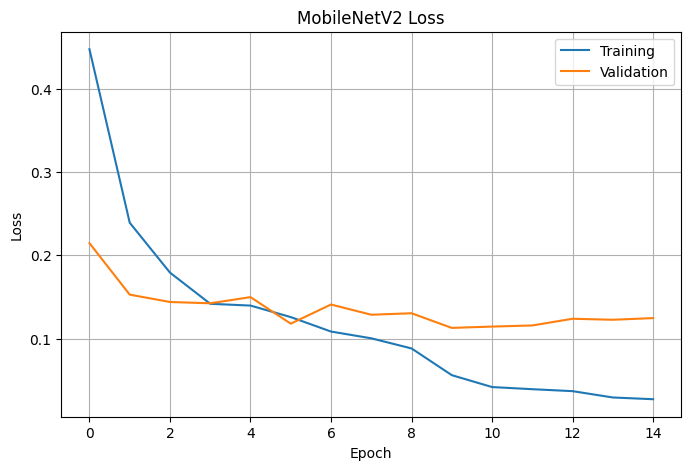

In [253]:

plt.figure(figsize=(8,5))

plt.plot(history_mobile.history['loss'],
         label='Training')

plt.plot(history_mobile.history['val_loss'],
         label='Validation')

plt.title("MobileNetV2 Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid()

plt.show()

70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step


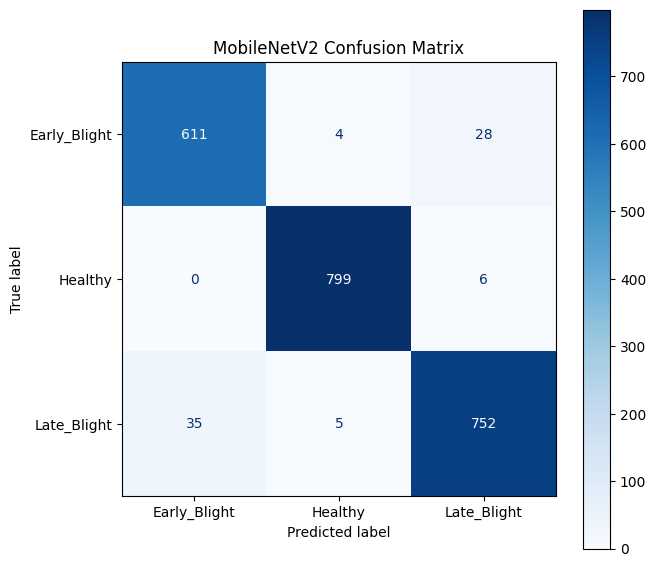

In [254]:

prediction_mobile = mobilenet_model.predict(valid_mobile)

prediction_mobile = np.argmax(prediction_mobile,axis=1)

true_mobile = valid_mobile.classes

cm = confusion_matrix(true_mobile,prediction_mobile)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=list(train_mobile.class_indices.keys())

)

fig,ax = plt.subplots(figsize=(7,7))

disp.plot(ax=ax,cmap="Blues")

plt.title("MobileNetV2 Confusion Matrix")

plt.show()

In [255]:

print(classification_report(

    true_mobile,

    prediction_mobile,

    target_names=list(train_mobile.class_indices.keys())

))

              precision    recall  f1-score   support

Early_Blight       0.95      0.95      0.95       643
     Healthy       0.99      0.99      0.99       805
 Late_Blight       0.96      0.95      0.95       792

    accuracy                           0.97      2240
   macro avg       0.96      0.96      0.96      2240
weighted avg       0.97      0.97      0.97      2240



In [213]:

mobilenet_model.save("MobileNetV2_Model.keras")

print("MobileNetV2 berhasil disimpan")

MobileNetV2 berhasil disimpan


In [256]:

import pandas as pd

hasil = pd.DataFrame({
    "Model": ["CNN", "MobileNetV2"],
    "Accuracy": [
        cnn_accuracy * 100,
        mobile_accuracy * 100
    ],
    "Loss": [
        cnn_loss,
        mobile_loss
    ]
})

hasil

,Model,Accuracy,Loss
0,CNN,92.053574,0.224169
1,MobileNetV2,96.517855,0.112907


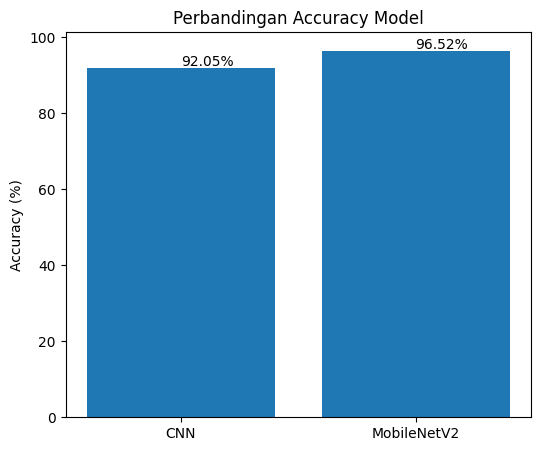

In [257]:

plt.figure(figsize=(6,5))

plt.bar(
    hasil["Model"],
    hasil["Accuracy"]
)

plt.ylabel("Accuracy (%)")

plt.title("Perbandingan Accuracy Model")

for i,v in enumerate(hasil["Accuracy"]):
    plt.text(i,v+0.5,f"{v:.2f}%")

plt.show()

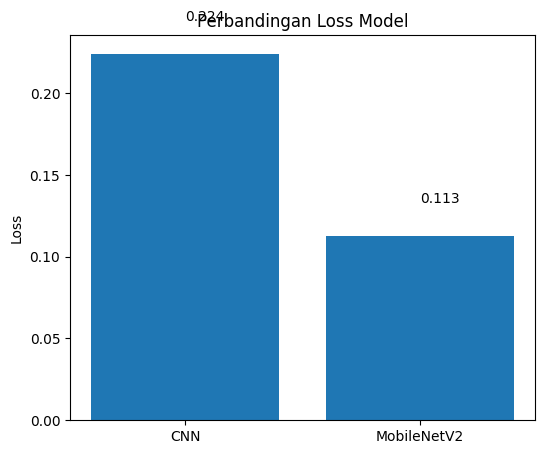

In [258]:

plt.figure(figsize=(6,5))

plt.bar(
    hasil["Model"],
    hasil["Loss"]
)

plt.ylabel("Loss")

plt.title("Perbandingan Loss Model")

for i,v in enumerate(hasil["Loss"]):
    plt.text(i,v+0.02,f"{v:.3f}")

plt.show()

In [260]:

hasil.to_csv(
    "Perbandingan_Model.csv",
    index=False
)

print("Perbandingan berhasil disimpan.")

Perbandingan berhasil disimpan.


In [261]:
for nama, nilai in zip(kelas, pred):
    print(f"{nama}: {nilai*100:.2f}%")

Early_Blight: 48.24%
Healthy: 1.99%
Late_Blight: 49.76%


PREDIKSI & PERBANDINGAN CNN vs MobileNetV2

Saving 0b494c44-8cd0-4491-bdfd-8a354209c3ae___RS_Erly.B 9561.JPG to 0b494c44-8cd0-4491-bdfd-8a354209c3ae___RS_Erly.B 9561.JPG


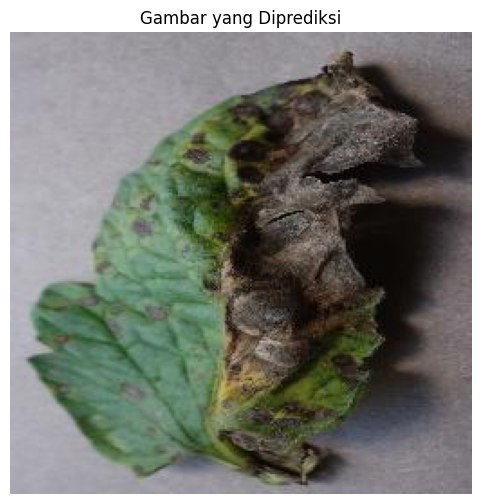

HASIL PREDIKSI
CNN          : Early_Blight (77.51%)
MobileNetV2  : Early_Blight (64.37%)


,Kelas,CNN (%),MobileNetV2 (%)
0,Early_Blight,77.510002,64.370003
1,Healthy,0.480000,0.000000
2,Late_Blight,22.020000,35.630001



Model dengan probabilitas terbesar:
✓ CNN         : Early_Blight
✓ MobileNetV2 : Early_Blight


In [267]:

from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Upload gambar
uploaded = files.upload()

# Nama kelas
kelas = ['Early_Blight','Healthy','Late_Blight']

for nama_file in uploaded.keys():


    img = image.load_img(nama_file)

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Gambar yang Diprediksi")
    plt.show()


    img224 = image.load_img(nama_file, target_size=(224,224))
    img224 = image.img_to_array(img224)/255.0
    img224 = np.expand_dims(img224, axis=0)


    pred_cnn = cnn_model.predict(img224, verbose=0)
    cnn_idx = np.argmax(pred_cnn)
    cnn_class = kelas[cnn_idx]
    cnn_conf = np.max(pred_cnn)*100

    pred_mobile = mobilenet_model.predict(img224, verbose=0)
    mobile_idx = np.argmax(pred_mobile)
    mobile_class = kelas[mobile_idx]
    mobile_conf = np.max(pred_mobile)*100

    print("="*60)
    print("HASIL PREDIKSI")
    print("="*60)

    print(f"CNN          : {cnn_class} ({cnn_conf:.2f}%)")
    print(f"MobileNetV2  : {mobile_class} ({mobile_conf:.2f}%)")


    hasil = pd.DataFrame({
        'Kelas':kelas,
        'CNN (%)':np.round(pred_cnn[0]*100,2),
        'MobileNetV2 (%)':np.round(pred_mobile[0]*100,2)
    })

    display(hasil)

    print("\nModel dengan probabilitas terbesar:")
    print(f"✓ CNN         : {cnn_class}")
    print(f"✓ MobileNetV2 : {mobile_class}")

In [268]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np

img = load_img(image_path, target_size=(224,224))
img_array = img_to_array(img)
img_array = preprocess_input(img_array)
img_array = np.expand_dims(img_array, axis=0)

hasil_prediksi = mobilenet_model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


In [269]:

print("===== HASIL AKHIR =====")

print()

print("CNN Accuracy         :",round(cnn_accuracy*100,2),"%")

print("MobileNetV2 Accuracy :",round(mobile_accuracy*100,2),"%")

print()

if mobile_accuracy > cnn_accuracy:
    print("Model Terbaik : MobileNetV2")
else:
    print("Model Terbaik : CNN")

===== HASIL AKHIR =====

CNN Accuracy         : 92.05 %
MobileNetV2 Accuracy : 96.52 %

Model Terbaik : MobileNetV2


PERBANDINGAN HASIL AKHIR

         Model   Accuracy      Loss
0          CNN  92.053574  0.224169
1  MobileNetV2  96.517855  0.112907


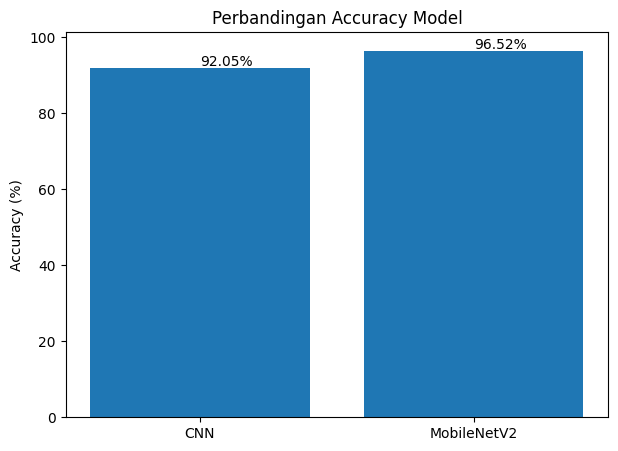

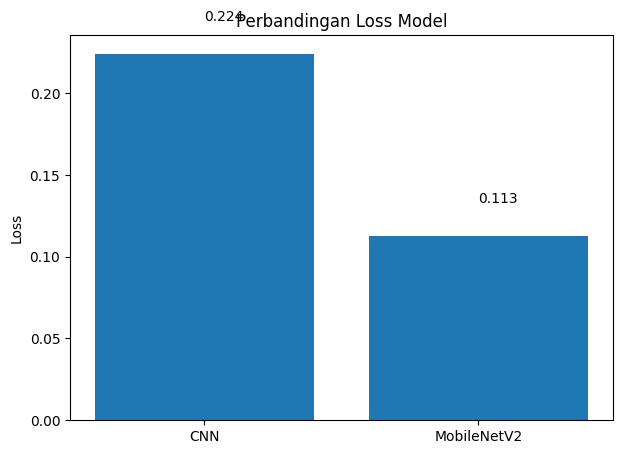

In [270]:

import pandas as pd

hasil = pd.DataFrame({
    "Model": ["CNN", "MobileNetV2"],
    "Accuracy": [cnn_accuracy*100, mobile_accuracy*100],
    "Loss": [cnn_loss, mobile_loss]
})

print(hasil)

plt.figure(figsize=(7,5))

plt.bar(
    hasil["Model"],
    hasil["Accuracy"]
)

for i, v in enumerate(hasil["Accuracy"]):
    plt.text(i, v+0.5, f"{v:.2f}%")

plt.title("Perbandingan Accuracy Model")
plt.ylabel("Accuracy (%)")

plt.show()

plt.figure(figsize=(7,5))

plt.bar(
    hasil["Model"],
    hasil["Loss"]
)

for i, v in enumerate(hasil["Loss"]):
    plt.text(i, v+0.02, f"{v:.3f}")

plt.title("Perbandingan Loss Model")
plt.ylabel("Loss")

plt.show()

PERBANDINGAN PRECISION, RECALL, DAN F1-SCORE

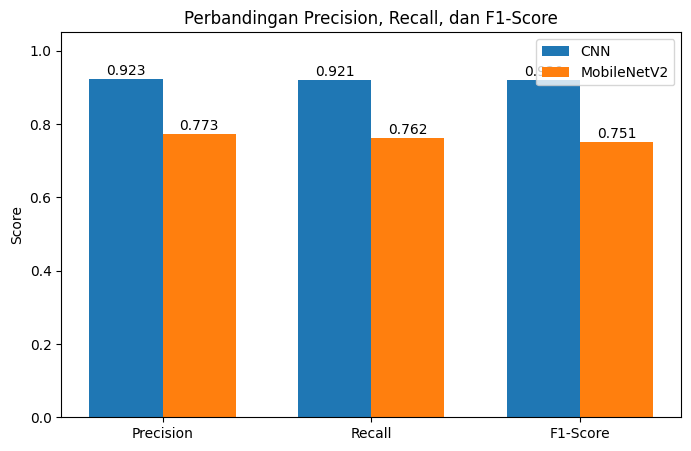

In [271]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Reset generator
valid_cnn.reset()

# Label asli
y_true = valid_cnn.classes

cnn_pred = cnn_model.predict(valid_cnn, verbose=0)
cnn_pred = np.argmax(cnn_pred, axis=1)

valid_cnn.reset()

mobilenet_pred = mobilenet_model.predict(valid_cnn, verbose=0)
mobilenet_pred = np.argmax(mobilenet_pred, axis=1)


cnn_precision = precision_score(y_true, cnn_pred, average='weighted')
cnn_recall = recall_score(y_true, cnn_pred, average='weighted')
cnn_f1 = f1_score(y_true, cnn_pred, average='weighted')


mobilenet_precision = precision_score(y_true, mobilenet_pred, average='weighted')
mobilenet_recall = recall_score(y_true, mobilenet_pred, average='weighted')
mobilenet_f1 = f1_score(y_true, mobilenet_pred, average='weighted')

labels = ['Precision', 'Recall', 'F1-Score']

cnn_scores = [cnn_precision, cnn_recall, cnn_f1]
mobilenet_scores = [mobilenet_precision, mobilenet_recall, mobilenet_f1]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, cnn_scores, width, label='CNN')
plt.bar(x + width/2, mobilenet_scores, width, label='MobileNetV2')

plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("Perbandingan Precision, Recall, dan F1-Score")
plt.ylim(0, 1.05)
plt.legend()

for i, v in enumerate(cnn_scores):
    plt.text(i-width/2, v+0.01, f"{v:.3f}", ha='center')

for i, v in enumerate(mobilenet_scores):
    plt.text(i+width/2, v+0.01, f"{v:.3f}", ha='center')

plt.show()